In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
import random
import keras

In [38]:
import sys
import os
sys.path.append(os.path.abspath("../"))
from LSTM.preprocessing import parse_start_time, convert_to_datetime, create_sequences, create_sequences_autoencoder

In [39]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [40]:
discharge_dataset = pd.read_csv("../../dataset/processed/discharge_data.csv")

discharge_data = discharge_dataset[discharge_dataset["battery_id"] == "B0005"].copy()

In [41]:
discharge_data["start_time"] = discharge_data["start_time"].apply(parse_start_time)

discharge_data["datetime"] = discharge_data["start_time"].apply(convert_to_datetime)

discharge_data["delta_time"] = (discharge_data["datetime"] - discharge_data["datetime"].iloc[0]).dt.total_seconds()

In [42]:
from LSTM.preprocessing import create_sequence, prepare_sequences_from_cycles

## Extract features

### Take 175 timesteps in each of the cycle, and then concatenate 168 cycles, each cycle have 5 features

In [43]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 181.04it/s]


In [44]:
# (cycles, each rows in a cycle, features)
X.shape

(168, 175, 5)

In [45]:
timesteps = X.shape[1]
features = X.shape[2]
latent_dim = 16

In [46]:
from keras.api.models import Model, Sequential
from keras.api.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from keras.api.utils import plot_model
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='sigmoid', return_sequences=True)(input_layer)
encoded = LSTM(32, activation='sigmoid', return_sequences=False)(encoded)
encoded = Dense(latent_dim, activation='relu', name='bottleneck')(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation='sigmoid', return_sequences=True)(decoded)
decoded = LSTM(64, activation='sigmoid', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features, activation='linear'))(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [47]:
# plot_model(autoencoder, show_shapes=True)

In [48]:
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 175, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 175, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 175, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 175, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 175, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 175, 5)         │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,293 (243.33 KB)

 Trainable params: 62,293 (243.33 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('autoencoder/best_autoencoder.keras', save_best_only=True)
]

autoencoder.fit(X, X, epochs=100, batch_size=32, validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 880ms/step - loss: 0.2334 - root_mean_squared_error: 0.4819 - val_loss: 0.0759 - val_root_mean_squared_error: 0.2754
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - loss: 0.0654 - root_mean_squared_error: 0.2555 - val_loss: 0.0191 - val_root_mean_squared_error: 0.1382
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - loss: 0.0570 - root_mean_squared_error: 0.2386 - val_loss: 0.0265 - val_root_mean_squared_error: 0.1628
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - loss: 0.0628 - root_mean_squared_error: 0.2505 - val_loss: 0.0226 - val_root_mean_squared_error: 0.1503
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - loss: 0.0496 - root_mean_squared_error: 0.2226 - val_loss: 0.0305 - val_root_mean_squared_error: 0.1748
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - loss: 0.0489 - root_mean_squared_error: 0.2211 - val_loss: 0.0391 - val_root_mean_squared_error: 0.1976
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - loss

In [50]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


In [51]:
encoded_features.shape

(168, 16)

In [52]:
capacity = discharge_data["Capacity"]

In [53]:
capacity.shape

(168,)

In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

In [55]:
combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1))) # (168, 33)

In [56]:
# (Cycles, seq_len, features)
combined_features.shape

(168, 17)

In [57]:
n_in = 20  # How many past cycles to use for prediction
n_out = 20

X, y = create_sequences(combined_features, n_in)

X_train, y_train = X[:140], y[:140]
X_val, y_val = X[140:], y[140:]

In [58]:
X.shape, y.shape

((148, 20, 17), (148, 17))

In [59]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((140, 20, 17), (140, 17), (8, 20, 17), (8, 17))

# Encoder-Decoder Model for future prediction

In [60]:
# df_combined = pd.DataFrame(combined_features)

In [61]:
# X_sequences, y_labels = create_sequence(df_combined, seq_length=15, target=100)

In [62]:
# print("X_sequences shape:", .shape)  # (128, 20, 33)
# print("y_labels shape:", y_seq.shape) # (128, 20, 33)

In [63]:
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

In [64]:
from keras.api.models import Sequential
from keras.api.layers import LSTM, RepeatVector, TimeDistributed, Dense, InputLayer, Dropout

# output_steps = 20
# features = X_seq.shape[2]

# input_layer_2 = Input(shape=(n_in, features))
# encoded_2 = LSTM(64, activation='relu', return_sequences=True)(input_layer_2)
# encoded_2 = LSTM(32, activation='relu', return_sequences=False)(encoded_2)

# decoded_2 = RepeatVector(n_out)(encoded_2)
# decoded_2 = LSTM(32, activation='relu', return_sequences=True)(decoded_2)
# decoded_2 = LSTM(64, activation='relu', return_sequences=True)(decoded_2)
# decoded_2 = TimeDistributed(Dense(1))(decoded_2)

# autoencoder_2 = Model(inputs=input_layer_2, outputs=decoded_2)

model = Sequential()

model.add(InputLayer((timesteps, n_features)))

model.add(LSTM(64, return_sequences=True, activation='tanh'))

model.add(LSTM(32, return_sequences=False, activation='tanh'))

model.add(Dense(8, activation='relu'))
model.add(Dense(latent_dim + 1, activation='linear'))

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 20, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,825 (132.13 KB)

 Trainable params: 33,825 (132.13 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError
from keras.api.regularizers import L2

# Callback to stop training when validation loss stops improving
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

cp = ModelCheckpoint('models/model.keras', save_best_only=True, monitor='val_loss')
model.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [67]:
model.fit(X, y, epochs=100, callbacks=[es, cp])

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0539 - root_mean_squared_error: 0.2322
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0492 - root_mean_squared_error: 0.2217
Epoch 3/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0475 - root_mean_squared_error: 0.2179

c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,root_mean_squared_error
  current = self.get_monitor_value(logs)
c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0468 - root_mean_squared_error: 0.2163
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0447 - root_mean_squared_error: 0.2114
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0426 - root_mean_squared_error: 0.2064
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0404 - root_mean_squared_error: 0.2011
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0383 - root_mean_squared_error: 0.1958
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0363 - root_mean_squared_error: 0.1904
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0342 - root_mean_squared_error: 0.1849
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0322 - root_mean_squared_error: 0.1794
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0302 - root_mean_squared_error: 0.1738
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0282 - root_mean_squared_error: 0.1679
Epoch 13/100
5/5 ━━

In [68]:
# X_test = X_test.reshape(1, n_in, features) # (1, 20, 33)
# X_test.shape

In [69]:
initial_input = combined_features[:n_in] # (20, 33)
X_input = initial_input.reshape(1, n_in, 17) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = scaler.inverse_transform([[initial_capacity]])[0, 0]
threshold = 0.7 * initial_capacity_real

print(f"Initial capacity: {initial_capacity_real} Ah")

Initial capacity: 1.8564874208181568 Ah


In [70]:
predicted_capacities = []
current_input = X_input.copy()
i = 2

while i < 200:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i}: {capacity_pred_real}")

    if capacity_pred_real < threshold:
        break

    next_step = np.zeros((1, 1, 17))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

Predicted capacity for cycle 2: 1.8030814511071114
Predicted capacity for cycle 3: 1.8021196293330595
Predicted capacity for cycle 4: 1.8009089237104288
Predicted capacity for cycle 5: 1.799529989157715
Predicted capacity for cycle 6: 1.7979801801393238
Predicted capacity for cycle 7: 1.7963021643959904
Predicted capacity for cycle 8: 1.7945147659309801
Predicted capacity for cycle 9: 1.792642269404361
Predicted capacity for cycle 10: 1.7907292079986332
Predicted capacity for cycle 11: 1.788738747718218
Predicted capacity for cycle 12: 1.7866738732699394
Predicted capacity for cycle 13: 1.7845386886256804
Predicted capacity for cycle 14: 1.782377421713834
Predicted capacity for cycle 15: 1.780141672799878
Predicted capacity for cycle 16: 1.777835681524188
Predicted capacity for cycle 17: 1.7755034723124183
Predicted capacity for cycle 18: 1.7730949156567744
Predicted capacity for cycle 19: 1.7706103846456087
Predicted capacity for cycle 20: 1.768052762234377
Predicted capacity for cycl

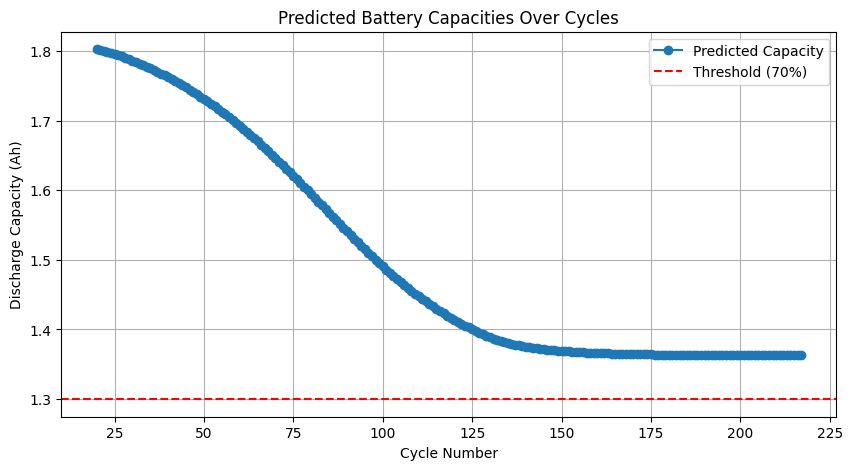

In [71]:
import matplotlib.pyplot as plt

# Create an array for cycle numbers starting from n_in
cycles = list(range(n_in, n_in + len(predicted_capacities)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cycles, predicted_capacities, marker='o', label='Predicted Capacity')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (70%)')
plt.title("Predicted Battery Capacities Over Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

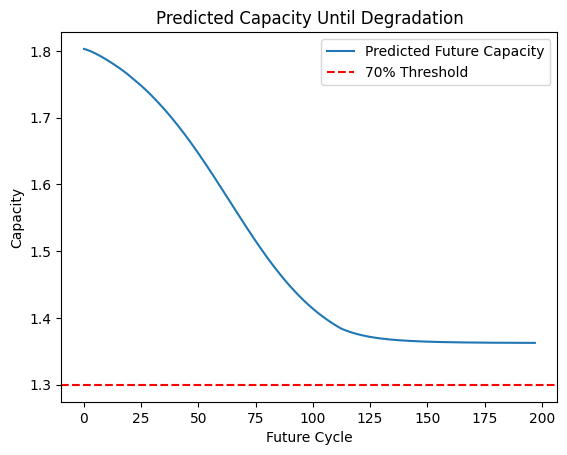

In [72]:
import matplotlib.pyplot as plt

plt.plot(predicted_capacities, label="Predicted Future Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="70% Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()